In [1]:
from src.data.bayesian_b_updater import BayesianGRBUpdater# %%
import src
from src.data.preparation import prepare_data_tpp
from config.config_loader import load_args_from_yaml 

In [2]:
args= load_args_from_yaml("../config/mixer_tpp.yaml")
args.dataset = 'AZDX'
base_dir = f"../data/{args.dataset}"
# %%
seq, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(base_dir=base_dir, args=args,)

Processed B_range: [0.0001, 0.01]
Using catalog dataset class: <class 'src.catalogs.azdx.AZDXStandard'>
Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/AZDX/raw.
Using Bayesian GR b-value updater with delta=0.998, a0=50.0, init b=1.0000
Number of training events: 64347
Number of validation events: 28318
Splitting into minibatches


  0%|          | 0/214 [00:00<?, ?it/s]

[split_sequence] Window duration: 2031.1242
[split_sequence] Window duration: 2068.5074
[split_sequence] Window duration: 2105.8905
[split_sequence] Window duration: 2143.2737
[split_sequence] Window duration: 2180.6569
[split_sequence] Window duration: 2218.0401
[split_sequence] Window duration: 2255.4232
[split_sequence] Window duration: 2292.8064
[split_sequence] Window duration: 2330.1896
[split_sequence] Window duration: 2367.5728
[split_sequence] Window duration: 2404.9560
[split_sequence] Window duration: 2442.3391
[split_sequence] Window duration: 2479.7223
[split_sequence] Window duration: 2517.1055
[split_sequence] Window duration: 2554.4887
[split_sequence] Window duration: 2591.8718
[split_sequence] Window duration: 2629.2550
[split_sequence] Window duration: 2666.6382
[split_sequence] Window duration: 2704.0214
[split_sequence] Window duration: 2741.4046
[split_sequence] Window duration: 2778.7877
[split_sequence] Window duration: 2816.1709
[split_sequence] Window duration

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:182: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


[split_sequence] Window duration: 4124.5821
[split_sequence] Window duration: 4161.9653
[split_sequence] Window duration: 4199.3485
[split_sequence] Window duration: 4236.7317
[split_sequence] Window duration: 4274.1148
[split_sequence] Window duration: 4311.4980
[split_sequence] Window duration: 4348.8812
[split_sequence] Window duration: 4386.2644
[split_sequence] Window duration: 4423.6475
[split_sequence] Window duration: 4461.0307
[split_sequence] Window duration: 4498.4139
[split_sequence] Window duration: 4535.7971
[split_sequence] Window duration: 4573.1803
[split_sequence] Window duration: 4610.5634
[split_sequence] Window duration: 4647.9466
[split_sequence] Window duration: 4685.3298
[split_sequence] Window duration: 4722.7130
[split_sequence] Window duration: 4760.0961
[split_sequence] Window duration: 4797.4793
[split_sequence] Window duration: 4834.8625
[split_sequence] Window duration: 4766.7807
[split_sequence] Window duration: 4720.6348
[split_sequence] Window duration

  0%|          | 0/94 [00:00<?, ?it/s]

[split_sequence] Window duration: 4925.3414
[split_sequence] Window duration: 4956.1530
[split_sequence] Window duration: 4977.1946
[split_sequence] Window duration: 4991.4261
[split_sequence] Window duration: 5003.3276
[split_sequence] Window duration: 5029.3989
[split_sequence] Window duration: 5033.1602
[split_sequence] Window duration: 5060.3420
[split_sequence] Window duration: 5079.3132
[split_sequence] Window duration: 5095.0448
[split_sequence] Window duration: 5129.1264
[split_sequence] Window duration: 5118.1778
[split_sequence] Window duration: 5130.4894
[split_sequence] Window duration: 5162.7009
[split_sequence] Window duration: 5156.0926
[split_sequence] Window duration: 5169.6337
[split_sequence] Window duration: 5204.4453
[split_sequence] Window duration: 5203.5767
[split_sequence] Window duration: 5196.1383
[split_sequence] Window duration: 5197.2497
[split_sequence] Window duration: 5215.6414
[split_sequence] Window duration: 5237.4828
[split_sequence] Window duration

  0%|          | 0/89 [00:00<?, ?it/s]

[split_sequence] Window duration: 6366.4184
[split_sequence] Window duration: 6393.7381
[split_sequence] Window duration: 6431.3763
[split_sequence] Window duration: 6429.9558
[split_sequence] Window duration: 6464.0646
[split_sequence] Window duration: 6496.6529
[split_sequence] Window duration: 6521.8516
[split_sequence] Window duration: 6547.4008
[split_sequence] Window duration: 6589.0702
[split_sequence] Window duration: 6628.8684
[split_sequence] Window duration: 6660.5173
[split_sequence] Window duration: 6648.1564
[split_sequence] Window duration: 6651.9253
[split_sequence] Window duration: 6677.4638
[split_sequence] Window duration: 6701.0131
[split_sequence] Window duration: 6731.3016
[split_sequence] Window duration: 6769.0003
[split_sequence] Window duration: 6756.0095
[split_sequence] Window duration: 6774.4278
[split_sequence] Window duration: 6787.4068
[split_sequence] Window duration: 6786.3261
[split_sequence] Window duration: 6807.7650
[split_sequence] Window duration

In [4]:
seq

Sequence(
  inter_times: [136453],
  arrival_times: [136452],
  t_start: 0.0,
  t_end: 19886.0,
  t_nll_start: 0.0,
  mag: [136452],
  loc: [136452, 2],
  depth: [136452],
  a_t: [136452],
  s_t: [136452],
  b_mean: [136452],
  b_sd: [136452],
  b_lo: [136452],
  b_hi: [136452],
  used_mask: [136452]
)

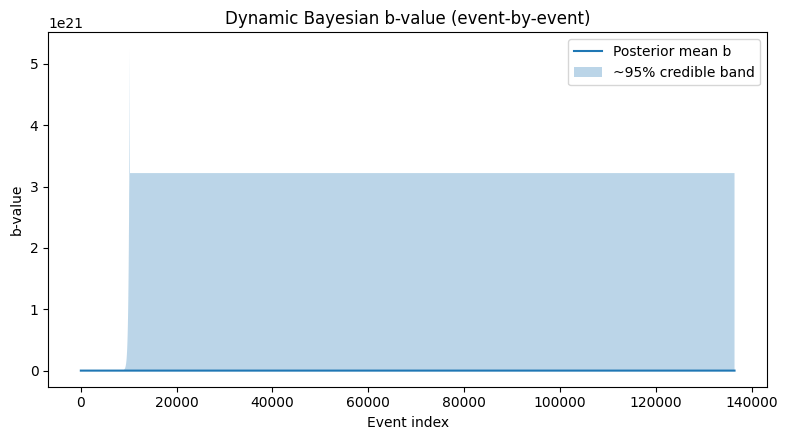

In [5]:
updater = BayesianGRBUpdater(Mc=4.5, delta=0.99, a0=50, init_b_target=1, mag_key="mag", write_back=True)
results = updater.fit(seq)            # 逐事件更新；同时把结果字段写回0 seq
BayesianGRBUpdater.plot(seq)          # 绘图（可选传入 truth_lines / switch_index）

似然最大取值与Gamma分布期望的差异

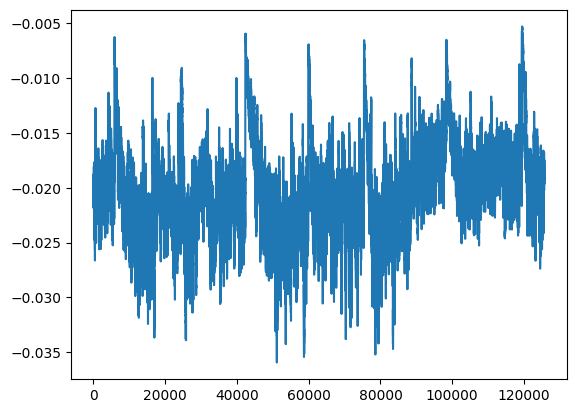

In [ ]:
import math
import matplotlib.pyplot as plt
diff = (seq.a_t-1)/(math.log(10)*seq.s_t)-(seq.a_t)/(math.log(10)*seq.s_t)  
# diff.mean()
# diff.max()
plt.plot(diff)